# JLM and JLMB optical potentials


In [29]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

In [30]:
from jitr import folding
from jitr.folding import jlm
from jitr.utils import density

# Folding with the nuclear matter self energy

The JLM nuclear matter self energy is included in jitr, as defined in the seminal works [JLM, 1977b](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.16.80), and [JLM, 1977a](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.15.10) which used Brueckner-Hartree Fock calculations of the self-energy in symmetric nuclear matter and nuclear matter with neutron excess, using Reid's hard core interaction, at various matter densities (Fermi momenta) and a range of positive energies from 10 to 160 MeV.

The nuclear matter self-energy is modeled with an isoscalar and isovector component:

\begin{equation}
U(\rho,E) = V_0(\rho,E) + i W(\rho,E) \pm \alpha \left( V_0(\rho,E) + i W(\rho,E) \right),
\end{equation}

with $\alpha = (\rho_n - \rho_p) / (\rho_n + \rho_p)$, and the $+(-)$ sign is for neutrons(protons).

The isoscalar real self energy, $V_0(\rho,E)$ was parameterized as a polynomial fit to the BHF results:

\begin{equation}
V_0(\rho,E) = \sum_{ij} a_{ij} \rho^i E^{j-1}.
\end{equation}

The isoscalar imaginary part $W_0(\rho,E)$ was parameterized as 


\begin{equation}
W_0(\rho,E) = \frac{\sum_{ij} d_{ij} \rho^i E^{j-1} }{1 + D / (E -\epsilon_F)^2} ,
\end{equation}

with $D=600$ and the Fermi energy parameterized from the Brueckner-Hartree-Fock result as:


\begin{equation}
\epsilon_F(\rho) = \sum_{i=1}^3 k_{i} \rho^i.
\end{equation}

The isovector real and imaginary parts are respectively defined as 


\begin{align}
\begin{split}
V_1(\rho,E) &= \frac{\tilde{m}(\rho,E)}{m} \mathfrak{Re} N(\rho,E) \\ & \\ 
W_1(\rho,E) &=   \frac{m}{\bar{m}(\rho,E)} \mathfrak{Im} N(\rho,E),
\end{split}
\end{align}


where $N(\rho,E)$ is extracted from the Coulomb-corrected difference of the neutron and proton self-energies in nuclear matter, with a given neutron excess (See [JLM, 1977a](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.15.10)). $N$ is parameterized as:

\begin{align}
\begin{split}
\mathfrak{Re} N(\rho,E) &= \sum_{ij} b_{ij} \rho^i E^{j-1}  \\ & \\
\mathfrak{Im} N(\rho,E) &= \frac{\sum_{ij} f_{ij} \rho^i E^{j-1} }{1 + F / (E -\epsilon_F)},
\end{split}
\end{align}


with $F=1$. The $k$-mass, $\tilde{m}(\rho,E)$ is parameterized as 


\begin{equation}
\frac{\tilde{m}(\rho,E)}{m} = 1 - \sum_{ij} c_{ij} \rho^i E^{j-1}.
\end{equation}

The $E$-mass $\bar{m}(\rho,E)$ can be obtained from

\begin{equation}
\frac{m^\star(\rho,E)}{m} = \frac{\tilde{m}(\rho,E)}{m} \frac{\bar{m}(\rho,E)}{m},
\end{equation}

where the effective mass is defined
\begin{equation}
\frac{m^\star(\rho,E)}{m} = 1 - \frac{d}{dE} V_0(\rho,E) = 1 - \sum_{ij} (j-1) a_{ij} \rho^i E^{j-2}.
\end{equation}

In total, there are 5 coefficient matrices, $a$, $b$, $c$, $d$, $f$.

These are included in `jitr.folding.jlm`.


In [31]:
rho_sat_fm3 = 0.16

In [32]:
jlm.fermi_energy_MeV(rho_sat_fm3)

np.float64(-24.844800000000003)

In [66]:
rho_grid = np.linspace(0.01, 0.2, 50)
E_vals = np.linspace(0.1, 170, 80)

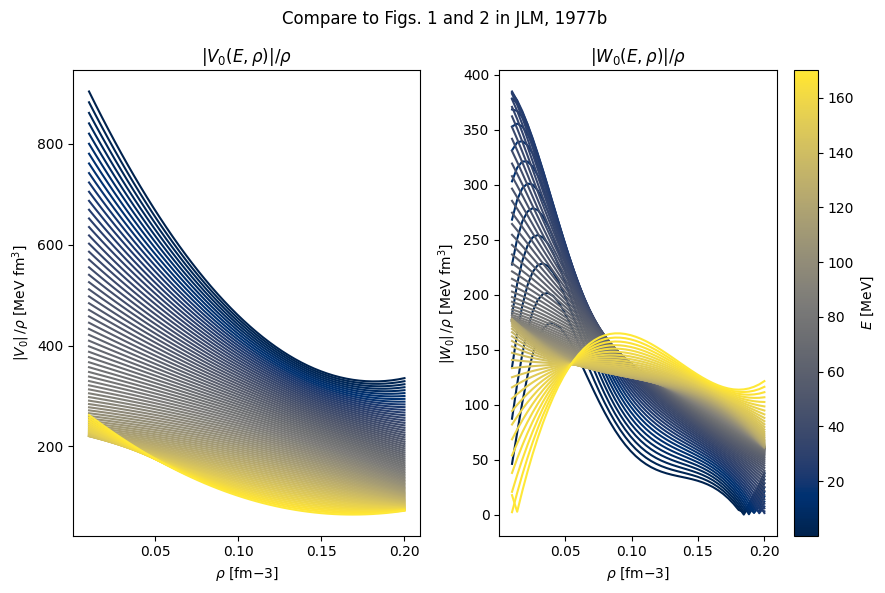

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(9, 6), sharey=False)
cmap = plt.cm.cividis
norm = mpl.colors.Normalize(vmin=E_vals.min(), vmax=E_vals.max())
E_F = jlm.fermi_energy_MeV(rho_grid)
for E in E_vals:
    
    axes[0].plot(
        rho_grid, 
        np.abs(jlm.V0(rho_grid, E)) / rho_grid, 
        color=cmap(norm(E)), 
        label=f"{E:1.0f} MeV",
    )
    axes[1].plot(
        rho_grid,
        np.abs(jlm.W0(rho_grid, E, E_F=E_F)) / rho_grid,
        label=f"{E:1.0f} MeV",
        color=cmap(norm(E)),
    )

axes[0].set_title(r"$|V_0(E,\rho)| / \rho$")
axes[0].set_ylabel(r"$|V_0 | \, / \rho $ [MeV fm$^3$]")
axes[0].set_xlabel(r"$\rho$ [fm${-3}$]")

axes[1].set_title(r"$|W_0(E,\rho)| / \rho$")
axes[1].set_xlabel(r"$\rho$ [fm${-3}$]")
axes[1].set_ylabel(r"$|W_0 | \, / \rho $ [MeV fm$^3$]")
#axes[1].legend()


sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes[1])
cbar.set_label("$E$ [MeV]")

fig.suptitle("Compare to Figs. 1 and 2 in JLM, 1977b")

plt.tight_layout()
plt.show()

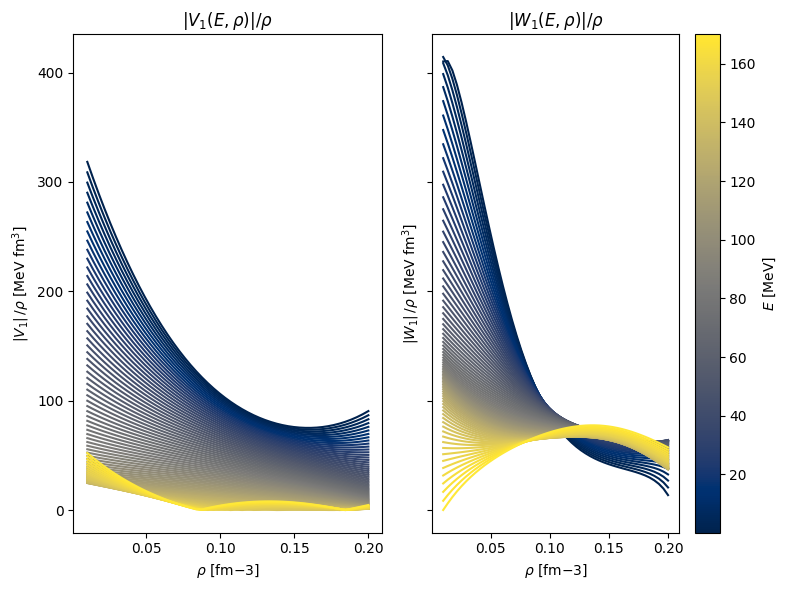

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
E_F = jlm.fermi_energy_MeV(rho_grid)
for E in E_vals:
    axes[0].plot(
        rho_grid, 
        np.abs(jlm.V1(rho_grid, E, E_F=E_F)) / rho_grid, 
        color=cmap(norm(E)), 
        label=f"{E:1.0f} MeV",
    )
    axes[1].plot(
        rho_grid,
        np.abs(jlm.W1(rho_grid, E, E_F=E_F)) / rho_grid,
        label=f"{E:1.0f} MeV",
        color=cmap(norm(E)),
    )

axes[0].set_title(r"$|V_1(E,\rho)| / \rho$")
axes[0].set_ylabel(r"$|V_1 | \, / \rho $ [MeV fm$^3$]")
axes[0].set_xlabel(r"$\rho$ [fm${-3}$]")

axes[1].set_title(r"$|W_1(E,\rho)| / \rho$")
axes[1].set_xlabel(r"$\rho$ [fm${-3}$]")
axes[1].set_ylabel(r"$|W_1 | \, / \rho $ [MeV fm$^3$]")
#axes[1].legend()
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes[1])
cbar.set_label("$E$ [MeV]")


plt.tight_layout()
plt.show()

## Folding to finite nuclear density
We will use the local density approximation and improved local density approximations. First, let's grab some density distributions:

In [78]:
def pb208_densities_2pf():
    rho_n = folding.TwoParameterFermiDensity(R=6.6, a=0.55, N=126)
    rho_p = folding.TwoParameterFermiDensity(R=6.3, a=0.547, N=82)
    return rho_p, rho_n

In [79]:
target = (208, 82)
neutron = (1,0)
proton = (1,1)

R = np.linspace(0.0, 12.0, 201)

rho_p_2pf, rho_n_2pf = pb208_densities_2pf()
rho_p_d1m, rho_n_d1m = density.densities(208, 82, R, model="d1m")
rho_p_bskg3, rho_n_bskg3 = density.densities(208, 82, R, model="bskg3")

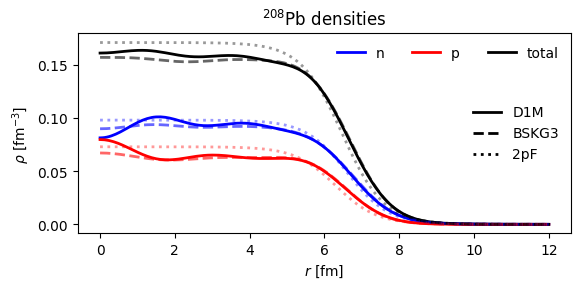

In [80]:
fig, ax = plt.subplots(figsize=(6, 3))
legend_handles_density_type = [
    ax.plot(R, rho_n_d1m, color="b", label="n", linewidth=2)[0],
    ax.plot(R, rho_p_d1m, color="r", label="p", linewidth=2)[0],
    ax.plot(R, rho_n_d1m + rho_p_d1m, color="k", label="total", linewidth=2)[0],
]

plt.plot(R, rho_n_bskg3, "--", color="b", linewidth=2, alpha=0.6)
plt.plot(R, rho_p_bskg3, "--", color="r", linewidth=2, alpha=0.6)
plt.plot(R, rho_n_bskg3 + rho_p_bskg3, "--", color="k", linewidth=2, alpha=0.6)


plt.plot(R, rho_n_2pf(R), ":", color="b", linewidth=2, alpha=0.4)
plt.plot(R, rho_p_2pf(R), ":", color="r", linewidth=2, alpha=0.4)
plt.plot(R, rho_n_2pf(R) + rho_p_2pf(R), ":", color="k", linewidth=2, alpha=0.4)

leg1 = ax.legend(
    handles=legend_handles_density_type, framealpha=0, ncol=3, loc="upper right"
)
leg2 = plt.legend(
    handles=[
        plt.plot([], [], color="k", linewidth=2, label="D1M")[0],
        plt.plot([], [], "--", color="k", linewidth=2, label="BSKG3")[0],
        plt.plot([], [], ":", color="k", linewidth=2, label="2pF")[0],
    ],
    framealpha=0,
    loc="center right",
)

ax.add_artist(leg1)

plt.xlabel(r"$r$ [fm]")
plt.ylabel(r"$\rho$ [fm$^{-3}$]")
plt.title(r"$^{208}$Pb densities")
plt.tight_layout()
plt.show()

### Local density approximation (LDA)

The LDA is a simple prescription. Given a nuclear matter self-energy $U(\rho,E)$ and a density profile $\rho(r)$:

\begin{equation}
U(r,E) = U(\rho(r),E)
\end{equation}

From [JLM, 1977b](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.16.80):

> [the] local density approximation
(LDA) ascribes to the OMP at the density $\rho(r)$ the
same value as in a uniform medium with the same
value of the density, with the same neutron excess,
and at the same energy.

In [81]:
from jitr.utils.constants import ALPHA, HBARC

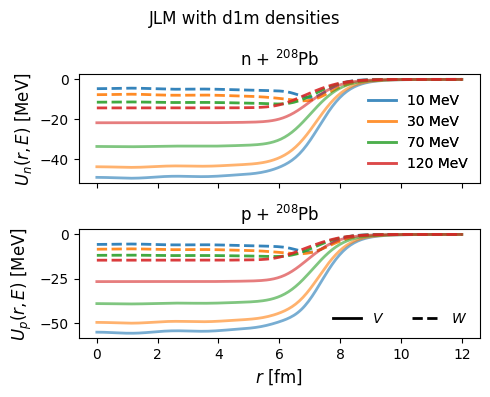

In [82]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(5, 4))
handles_energy = []
for E in [10, 30, 70, 120]:
    V, W = jlm.potential_JLM(R, rho_n_d1m + rho_p_d1m, (1, 0), target, E)
    (p,) = axes[0].plot(R, V, linewidth=2, label=f"{E:1.0f} MeV", alpha=0.6)
    axes[0].plot(R, W, "--", linewidth=2, color=p.get_color(), alpha=0.9)
    handles_energy.append(p)
    V, W = jlm.potential_JLM(R, rho_n_d1m + rho_p_d1m, (1, 1), target, E)
    axes[1].plot(R, V, linewidth=2, color=p.get_color(), alpha=0.6)
    axes[1].plot(R, W, "--", linewidth=2, color=p.get_color(), alpha=0.9)

leg1 = axes[0].legend(handles=handles_energy, framealpha=0, ncol=1, loc="lower right")
leg2 = axes[1].legend(
    handles=[
        plt.plot([], [], color="k", linewidth=2, label=r"$V$")[0],
        plt.plot([], [], "--", color="k", linewidth=2, label="$W$")[0],
    ],
    framealpha=0,
    ncol=2,
    loc="lower right",
)
axes[0].add_artist(leg1)


axes[1].set_xlabel(r"$r$ [fm]", fontsize=12)
axes[0].set_ylabel(r"$U_n(r,E)$ [MeV]", fontsize=12)
axes[1].set_ylabel(r"$U_p(r,E)$ [MeV]", fontsize=12)
axes[0].set_title(r"n + $^{208}$Pb", fontsize=12)
axes[1].set_title(r"p + $^{208}$Pb", fontsize=12)
fig.suptitle("JLM with d1m densities")
plt.tight_layout()
plt.show()

### Volume integrals in the LDA

In [83]:
energies = np.linspace(10,200,200)
Ju_A = np.zeros_like(energies, dtype=complex)
projectile = proton
A = target[0]
for i, E in enumerate(energies):
    V, W = jlm.potential_JLM(R, rho_n_d1m + rho_p_d1m, (1, 0), target, E)
    Jv_A = 4 * np.pi / A *  np.trapezoid(V*R**2, R)
    Jw_A = 4 * np.pi / A *  np.trapezoid(W*R**2, R)
    Ju_A[i] = Jv_A + 1j * Jw_A

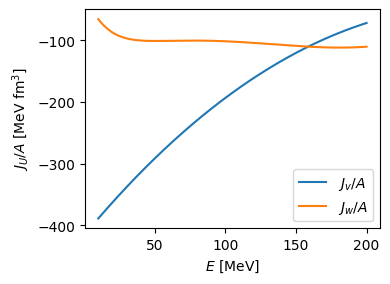

In [84]:
fig = plt.figure(figsize=(4,3))
plt.plot(energies, Ju_A.real, label=r"$J_v/A$")
plt.plot(energies, Ju_A.imag, label=r"$J_w/A$")
plt.legend()
plt.xlabel("$E$ [MeV]")
plt.ylabel("$J_U / A$ [MeV fm$^3$]")
plt.tight_layout()
plt.show()

## JLMB and the improved LDA (ILDA)

The JLM formalism was later updated to separately use the neutron and proton densities to determine the isovector dependence of the optical potential, as well renormalize the depths to fit elastic scattering experiments:

- [Bauge, Delaroche, & Girod, 1998](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.58.1118)
- [Bauge, Delaroche, & Girod, 2001](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.63.024607)

Additionally, rather than using the LDA as above, the finite nucleus self-energy as calculated above is convolved with a Gaussian with isovector-dependent range $t \sim 1$ fm.

In [85]:
folder = folding.ILDAFolder(r_max=20.0, n_quad=200)  # once

# interpolate densities onto quadrature grid
rho_n_q = folder.interp_to_quad(R, rho_n_d1m)
rho_p_q = folder.interp_to_quad(R, rho_p_d1m)

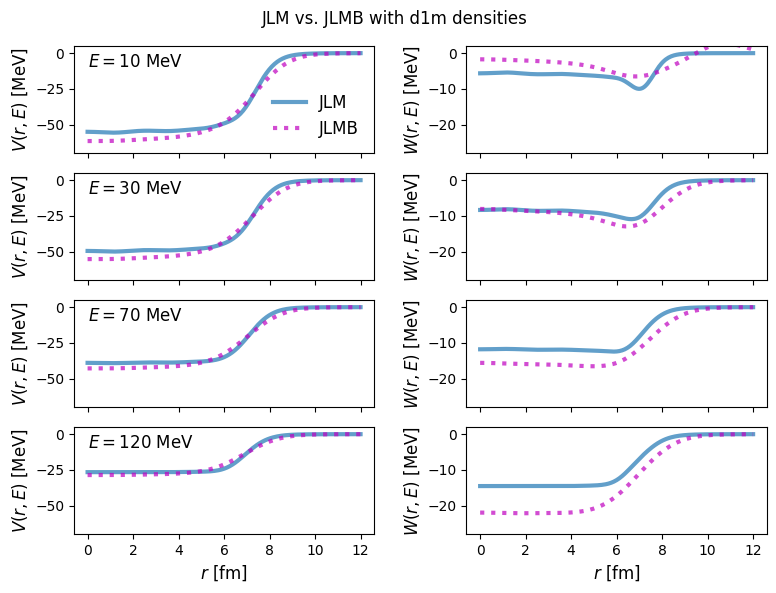

In [86]:
energies = [10, 30, 70, 120]
projectile = proton

fig, axes = plt.subplots(len(energies),2, sharex=True, figsize=(8, 6))
axes = np.array(axes)
for i, E in enumerate(energies):
    V_n_jlm, W_n_jlm = jlm.potential_JLM(R, rho_n_d1m + rho_p_d1m, projectile , target, E)
    V_n_jlmb, W_n_jlmb = jlm.potential_JLMB(
        folder,
        rho_n_q,
        rho_p_q,
        projectile,
        target,
        E,
        r_out=R,
        lambda_V=jlm.lambda_v0(E),
        lambda_V1=jlm.lambda_v1(E),
        lambda_W=jlm.lambda_w0(E),
        lambda_W1=jlm.lambda_w1(E),
    )

    axes[i,0].plot(R, V_n_jlm, linewidth=3, alpha=0.7, color='tab:blue', label='JLM')
    axes[i,0].plot(R, V_n_jlmb, ":", linewidth=3, color='m', alpha=0.7, label='JLMB')
    axes[i,0].set_ylabel(r"$V(r,E)$ [MeV]", fontsize=12)
    axes[i,0].text(0,-10, f"$E = ${E:1.0f} MeV", fontsize=12)
    axes[i,0].set_ylim([-70,5])

    axes[i,1].plot(R, W_n_jlm, linewidth=3, alpha=0.7, color='tab:blue', label='JLM')
    axes[i,1].plot(R, W_n_jlmb, ":", linewidth=3, color='m', alpha=0.7, label='JLMB')
    axes[i,1].set_ylabel(r"$W(r,E)$ [MeV]", fontsize=12)
    axes[i,1].set_ylim([-28,2])


axes[0,0].legend(loc="lower right", framealpha=0, fontsize=12)
axes[-1,0].set_xlabel(r"$r$ [fm]", fontsize=12)
axes[-1,1].set_xlabel(r"$r$ [fm]", fontsize=12)
fig.suptitle("JLM vs. JLMB with d1m densities")
plt.tight_layout()
plt.show()

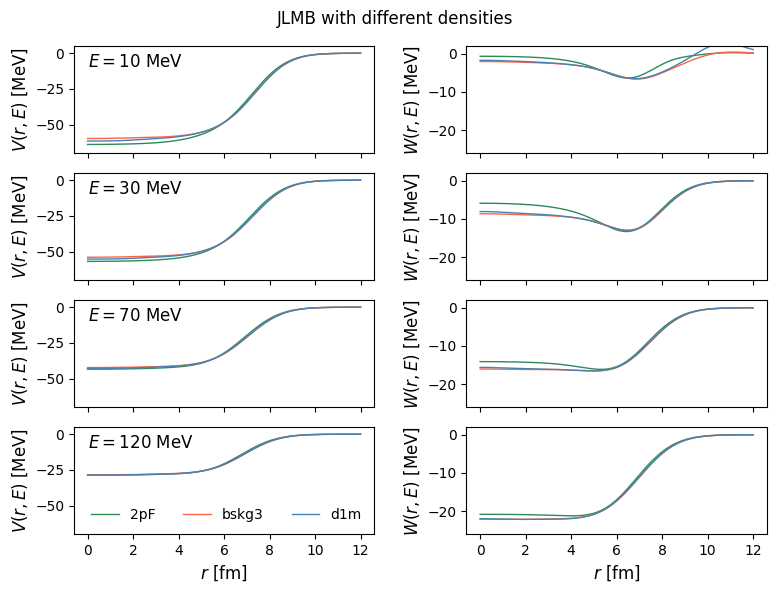

In [87]:
energies = [10, 30, 70, 120]
projectile = proton

# interpolate densities onto quadrature grid
densities_at_nodes = {
    label: (folder.interp_to_quad(R, rho_n), folder.interp_to_quad(R, rho_p))
    for label, rho_n, rho_p in [
        ("2pF", rho_n_2pf(R), rho_p_2pf(R)),
        ("bskg3", rho_n_bskg3, rho_p_bskg3),
        ("d1m", rho_n_d1m, rho_p_d1m),
    ]
}

colors = {
    '2pF' : '#2E8B57',
    'd1m' : '#4682B4',
    'bskg3': '#FF6347',
}

fig, axes = plt.subplots(len(energies),2, sharex=True, figsize=(8, 6))
axes = np.array(axes)
for i, E in enumerate(energies):
    for model_name, (rho_n_q, rho_p_q) in densities_at_nodes.items():
        V, W = jlm.potential_JLMB(
            folder,
            rho_n_q,
            rho_p_q,
            projectile,
            target,
            E,
            r_out=R,
            lambda_V=jlm.lambda_v0(E),
            lambda_V1=jlm.lambda_v1(E),
            lambda_W=jlm.lambda_w0(E),
            lambda_W1=jlm.lambda_w1(E),
        )

        axes[i,0].plot(R, V, linewidth=1, alpha=1, color=colors[model_name], label=model_name)
        axes[i,1].plot(R, W, linewidth=1, alpha=1, color=colors[model_name])

    axes[i,0].set_ylabel(r"$V(r,E)$ [MeV]", fontsize=12)
    axes[i,0].text(0,-10, f"$E = ${E:1.0f} MeV", fontsize=12)
    axes[i,0].set_ylim([-70,5])
    axes[i,1].set_ylabel(r"$W(r,E)$ [MeV]", fontsize=12)
    axes[i,1].set_ylim([-26,2])


axes[-1,0].legend(loc="lower right", framealpha=0, fontsize=10, ncol=3)
axes[-1,0].set_xlabel(r"$r$ [fm]", fontsize=12)
axes[-1,1].set_xlabel(r"$r$ [fm]", fontsize=12)
fig.suptitle("JLMB with different densities")
plt.tight_layout()
plt.show()

In [88]:
energies = np.linspace(0.01,300,200)
Ju_A_JLM = np.zeros_like(energies, dtype=complex)
Ju_A_JLMB = np.zeros_like(energies, dtype=complex)
Ju_A_JLMB_no_renorm = np.zeros_like(energies, dtype=complex)

projectile = neutron
A = target[0]
for i, E in enumerate(energies):
    V, W = jlm.potential_JLM(R, rho_n_d1m + rho_p_d1m, projectile, target, E)
    Ju_A_JLM[i] = np.trapezoid(V*R**2, R) + 1j *  np.trapezoid(W*R**2, R)

    V, W = jlm.potential_JLMB(
        folder,
        rho_n_q,
        rho_p_q,
        projectile,
        target,
        E,            
        lambda_V=jlm.lambda_v0(E),
        lambda_V1=jlm.lambda_v1(E),
        lambda_W=jlm.lambda_w0(E),
        lambda_W1=jlm.lambda_w1(E),
    )
    Ju_A_JLMB[i] = folder.integrate(V * folder.r_q**2) + 1j* folder.integrate(W* folder.r_q**2)

    V, W = jlm.potential_JLMB(
        folder,
        rho_n_q,
        rho_p_q,
        projectile,
        target,
        E,            
    )
    Ju_A_JLMB_no_renorm[i] = folder.integrate(V * folder.r_q**2) + 1j* folder.integrate(W* folder.r_q**2)

Ju_A_JLM *= 4 * np.pi / A 
Ju_A_JLMB *= 4 * np.pi / A 
Ju_A_JLMB_no_renorm *= 4 * np.pi / A 

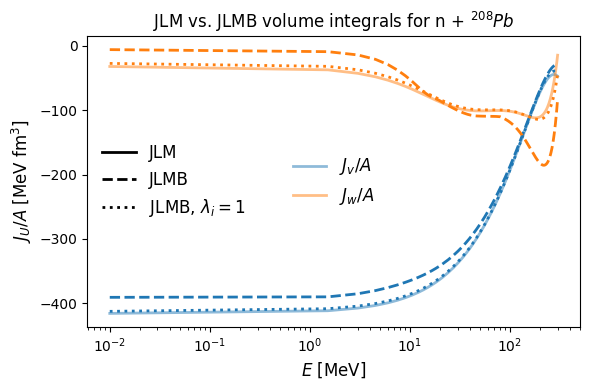

In [89]:
fig, ax = plt.subplots(1,1, figsize=(6,4))

legend_handles_term = [
    plt.plot(energies, Ju_A_JLM.real, linewidth=2,color='tab:blue', alpha=0.5, label=r"$J_v/A$")[0],
    plt.plot(energies, Ju_A_JLM.imag, linewidth=2,color='tab:orange',  alpha=0.5,label=r"$J_w/A$")[0],
]
plt.plot(energies, Ju_A_JLMB.real, "--",linewidth=2,color='tab:blue')
plt.plot(energies, Ju_A_JLMB.imag, "--", linewidth=2,color='tab:orange')
plt.plot(energies, Ju_A_JLMB_no_renorm.real, ":",linewidth=2,color='tab:blue')
plt.plot(energies, Ju_A_JLMB_no_renorm.imag, ":", linewidth=2,color='tab:orange')

leg1 = ax.legend(
    handles=legend_handles_term, framealpha=0, ncol=1, loc="center", fontsize=12,
)
leg2 = plt.legend(
    handles=[
                plt.plot([], [],  color="k", linewidth=2, label="JLM")[0],
        plt.plot([], [],"--", color='k',linewidth=2,  label="JLMB")[0],        
        plt.plot([], [],":", color='k',linewidth=2,  label=r"JLMB, $\lambda_i = 1$")[0], 
    ],
    framealpha=0,
    loc="center left",
    fontsize=12,
)
ax.add_artist(leg1)



plt.xscale("log")
plt.xlabel("$E$ [MeV]", fontsize=12)
plt.ylabel("$J_U / A$ [MeV fm$^3$]", fontsize=12)
ax.set_title(r"JLM vs. JLMB volume integrals for n + $^{208}Pb$", fontsize=12)
plt.tight_layout()
plt.show()

## Comparison of JLM and JLMB cross section predictions

## Effext of densities on cross sections